In [2]:
# CELL 1: SETUP & IMPORTS
import os
import time
import json
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Buat folder untuk menyimpan semua hasil agar tidak berantakan
SAVE_DIR = "results_exp2_group"
os.makedirs(SAVE_DIR, exist_ok=True)

# Cek ketersediaan GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")
if torch.cuda.is_available():
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")

Menggunakan device: cuda
Nama GPU: NVIDIA GeForce RTX 5070


In [3]:
# CELL 2: FOCAL LOSS
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [4]:
# CELL 3: DATASET & STRATIFIED GROUP K-FOLD (UPDATED LOCAL PATHS)
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
# BERUBAH: Import StratifiedGroupKFold
from sklearn.model_selection import StratifiedGroupKFold

# 1. Kunci Lokasi Data Lokal
data_dir = r"C:\Users\asfan\Data\ham10000\full"
csv_path = r"C:\Users\asfan\Data\ham10000\HAM10000_metadata.csv"

# 2. Baca Metadata dan Petakan Kelas
df = pd.read_csv(csv_path)
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
class_to_idx = {c: i for i, c in enumerate(class_names)}

# Mapping kelas teks ('dx') menjadi indeks angka
df['label'] = df['dx'].map(class_to_idx)

# Membangun full path untuk setiap gambar secara otomatis
df['image_path'] = df.apply(lambda row: os.path.join(data_dir, row['dx'], f"{row['image_id']}.jpg"), axis=1)

# Verifikasi path
print(f"Total data: {len(df)}")
print(f"Contoh path gambar: {df.iloc[0]['image_path']}")
if not os.path.exists(df.iloc[0]['image_path']):
    print("WARNING: Path gambar tidak ditemukan! Pastikan ekstensi .jpg atau nama folder sesuai.")

# 3. Class Dataset Kustom
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# 4. Augmentasi Data
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Persiapan Stratified Group 5-Fold (BERUBAH DI SINI)
X = df['image_path'].values
y = df['label'].values
# TAMBAHAN: Ambil kolom lesion_id sebagai dasar pengelompokan subjek/pasien
groups = df['lesion_id'].values 

# BERUBAH: Menggunakan StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

print("Dataset dan Stratified Group K-Fold siap!")

Total data: 10015
Contoh path gambar: C:\Users\asfan\Data\ham10000\full\bkl\ISIC_0027419.jpg
Dataset dan Stratified Group K-Fold siap!


In [5]:
# CELL 4 (REVISI UNTUK EXP 2): ConvNeXt + Spatial Attention
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        y = torch.cat([avg_out, max_out], dim=1)
        y = self.conv(y)
        return x * self.sigmoid(y)

class ConvNeXt_Spatial_Attention(nn.Module):
    def __init__(self, num_classes=7):
        super(ConvNeXt_Spatial_Attention, self).__init__()
        convnext = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        self.features = convnext.features
        
        # Menggunakan Spatial Attention sebagai pengganti SE
        self.spatial_attention = SpatialAttention(kernel_size=7)
        
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(1),
            nn.LayerNorm(768, eps=1e-6),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.spatial_attention(x) # Inject Spatial Attention di sini
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

In [6]:
# CELL 5: TRAINING ENGINE WITH METRIC TRACKING
def train_model(fold, model, train_loader, val_loader, criterion, optimizer, num_epochs=50):
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    start_time = time.time()
    torch.cuda.reset_peak_memory_stats()
    
    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            total += labels.size(0)
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct.double() / total
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)
                val_total += labels.size(0)
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct.double() / val_total
        
        # Simpan metrik
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_acc'].append(epoch_val_acc.item())
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
        
        # Simpan model terbaik (.pth)
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            model_save_path = os.path.join(SAVE_DIR, f"exp2_fold{fold}_best_model.pth")
            torch.save(model.state_dict(), model_save_path)
            
    # Kalkulasi performa hardware
    end_time = time.time()
    training_time = end_time - start_time
    max_memory = torch.cuda.max_memory_allocated() / (1024 ** 2) # Dalam MB
    
    # Simpan history ke JSON
    with open(os.path.join(SAVE_DIR, f"exp2_fold{fold}_history.json"), 'w') as f:
        json.dump(history, f)
        
    return history, training_time, max_memory

In [7]:
# CELL 6: EVALUATION & REPORTING
def evaluate_and_plot(fold, model, val_loader, history, training_time, max_memory, class_names):
    # Load model terbaik
    model.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"exp2_fold{fold}_best_model.pth")))
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 1. Classification Report & Metrics
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(SAVE_DIR, f"exp2_fold{fold}_classification_report.csv"))
    
    # Simpan resource metrik
    resource_log = {
        'training_time_seconds': training_time,
        'max_gpu_memory_mb': max_memory,
        'overall_accuracy': accuracy_score(all_labels, all_preds)
    }
    with open(os.path.join(SAVE_DIR, f"exp2_fold{fold}_resources.json"), 'w') as f:
        json.dump(resource_log, f)
        
    # 2. Plot Loss & Accuracy Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title(f'Loss Curve - Fold {fold}')
    ax1.legend()
    
    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_title(f'Accuracy Curve - Fold {fold}')
    ax2.legend()
    plt.savefig(os.path.join(SAVE_DIR, f"exp2_fold{fold}_learning_curves.png"))
    plt.show()
    
    # 3. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(os.path.join(SAVE_DIR, f"exp2_fold{fold}_confusion_matrix.png"))
    plt.show()
    
    print(f"Semua log dan grafik untuk Fold {fold} berhasil disimpan di folder: {SAVE_DIR}")

# CONTOH EKSEKUSI (Bisa diletakkan di dalam loop Stratified K-Fold)
# class_names = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
# criterion = FocalLoss(gamma=2)
# optimizer = optim.Adam(model.parameters(), lr=1e-4)
# history, t_time, max_mem = train_model(fold=1, model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer)
# evaluate_and_plot(fold=1, model=model, val_loader=val_loader, history=history, training_time=t_time, max_memory=max_mem, class_names=class_names)

Mulai Eksperimen 2: ConvNeXt + Spatial Attention + Focal Loss (Grouped by Patient)
Menyimpan di folder: results_exp2_group

---> Memulai Fold 1 <---
Epoch 1/50 - Train Loss: 0.4343 Acc: 0.7367 | Val Loss: 0.4027 Acc: 0.7205
Epoch 2/50 - Train Loss: 0.2545 Acc: 0.8091 | Val Loss: 0.3063 Acc: 0.7438
Epoch 3/50 - Train Loss: 0.2035 Acc: 0.8333 | Val Loss: 0.2584 Acc: 0.8213
Epoch 4/50 - Train Loss: 0.1306 Acc: 0.8854 | Val Loss: 0.2161 Acc: 0.8401
Epoch 5/50 - Train Loss: 0.1012 Acc: 0.9010 | Val Loss: 0.2174 Acc: 0.8357
Epoch 6/50 - Train Loss: 0.0765 Acc: 0.9228 | Val Loss: 0.2141 Acc: 0.8530
Epoch 7/50 - Train Loss: 0.0549 Acc: 0.9399 | Val Loss: 0.2341 Acc: 0.8486
Epoch 8/50 - Train Loss: 0.0479 Acc: 0.9461 | Val Loss: 0.2547 Acc: 0.8466
Epoch 9/50 - Train Loss: 0.0369 Acc: 0.9623 | Val Loss: 0.2794 Acc: 0.8366
Epoch 10/50 - Train Loss: 0.0276 Acc: 0.9690 | Val Loss: 0.2600 Acc: 0.8396
Epoch 11/50 - Train Loss: 0.0231 Acc: 0.9770 | Val Loss: 0.2421 Acc: 0.8535
Epoch 12/50 - Train Loss

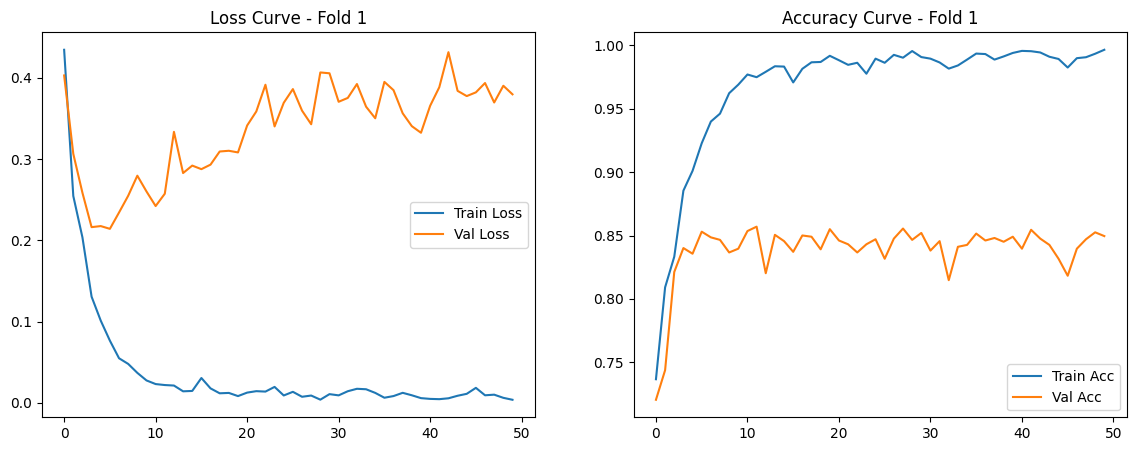

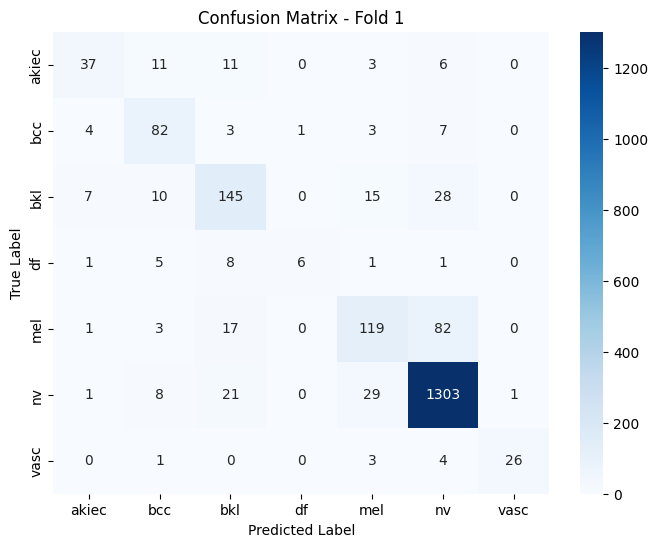

Semua log dan grafik untuk Fold 1 berhasil disimpan di folder: results_exp2_group

---> Memulai Fold 2 <---
Epoch 1/50 - Train Loss: 0.4159 Acc: 0.7402 | Val Loss: 0.2761 Acc: 0.8177
Epoch 2/50 - Train Loss: 0.2120 Acc: 0.8394 | Val Loss: 0.2163 Acc: 0.8363
Epoch 3/50 - Train Loss: 0.1412 Acc: 0.8768 | Val Loss: 0.2057 Acc: 0.8338
Epoch 4/50 - Train Loss: 0.1023 Acc: 0.9083 | Val Loss: 0.1817 Acc: 0.8568
Epoch 5/50 - Train Loss: 0.0758 Acc: 0.9302 | Val Loss: 0.1872 Acc: 0.8683
Epoch 6/50 - Train Loss: 0.0543 Acc: 0.9446 | Val Loss: 0.1939 Acc: 0.8583
Epoch 7/50 - Train Loss: 0.0449 Acc: 0.9541 | Val Loss: 0.2282 Acc: 0.8498
Epoch 8/50 - Train Loss: 0.0326 Acc: 0.9663 | Val Loss: 0.2195 Acc: 0.8683
Epoch 9/50 - Train Loss: 0.0325 Acc: 0.9689 | Val Loss: 0.2057 Acc: 0.8708
Epoch 10/50 - Train Loss: 0.0262 Acc: 0.9719 | Val Loss: 0.2220 Acc: 0.8543
Epoch 11/50 - Train Loss: 0.0181 Acc: 0.9822 | Val Loss: 0.2376 Acc: 0.8518
Epoch 12/50 - Train Loss: 0.0240 Acc: 0.9761 | Val Loss: 0.2555 A

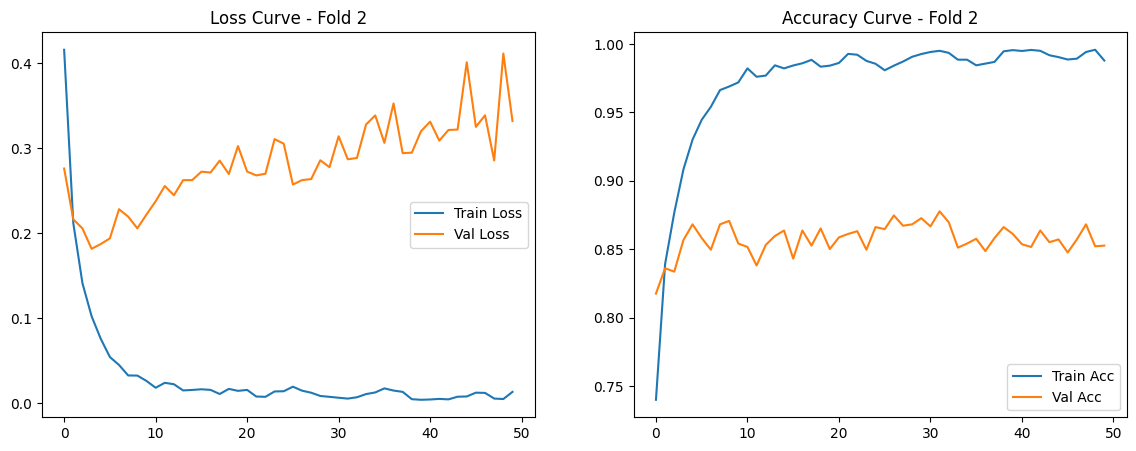

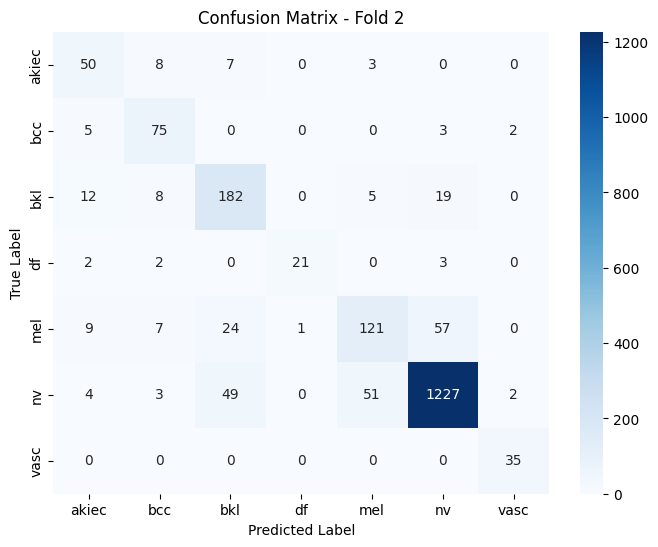

Semua log dan grafik untuk Fold 2 berhasil disimpan di folder: results_exp2_group

---> Memulai Fold 3 <---
Epoch 1/50 - Train Loss: 0.3750 Acc: 0.7569 | Val Loss: 0.2697 Acc: 0.8149
Epoch 2/50 - Train Loss: 0.1959 Acc: 0.8473 | Val Loss: 0.2478 Acc: 0.7915
Epoch 3/50 - Train Loss: 0.1377 Acc: 0.8786 | Val Loss: 0.2471 Acc: 0.7945
Epoch 4/50 - Train Loss: 0.0954 Acc: 0.9121 | Val Loss: 0.2132 Acc: 0.8502
Epoch 5/50 - Train Loss: 0.0724 Acc: 0.9320 | Val Loss: 0.2121 Acc: 0.8368
Epoch 6/50 - Train Loss: 0.0534 Acc: 0.9440 | Val Loss: 0.1971 Acc: 0.8597
Epoch 7/50 - Train Loss: 0.0383 Acc: 0.9616 | Val Loss: 0.2500 Acc: 0.8527
Epoch 8/50 - Train Loss: 0.0351 Acc: 0.9669 | Val Loss: 0.2580 Acc: 0.8488
Epoch 9/50 - Train Loss: 0.0273 Acc: 0.9715 | Val Loss: 0.2639 Acc: 0.8577
Epoch 10/50 - Train Loss: 0.0248 Acc: 0.9739 | Val Loss: 0.2732 Acc: 0.8517
Epoch 11/50 - Train Loss: 0.0233 Acc: 0.9745 | Val Loss: 0.2462 Acc: 0.8502
Epoch 12/50 - Train Loss: 0.0184 Acc: 0.9799 | Val Loss: 0.2709 A

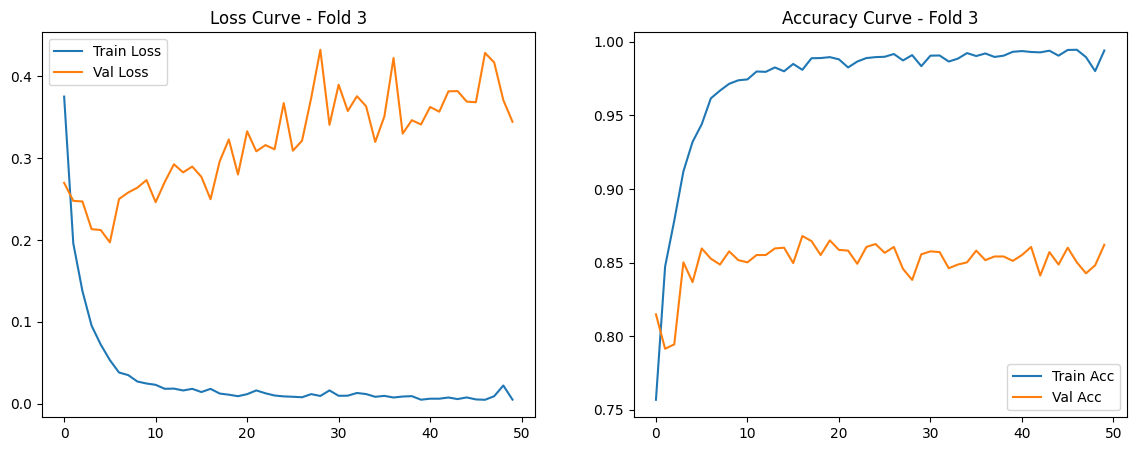

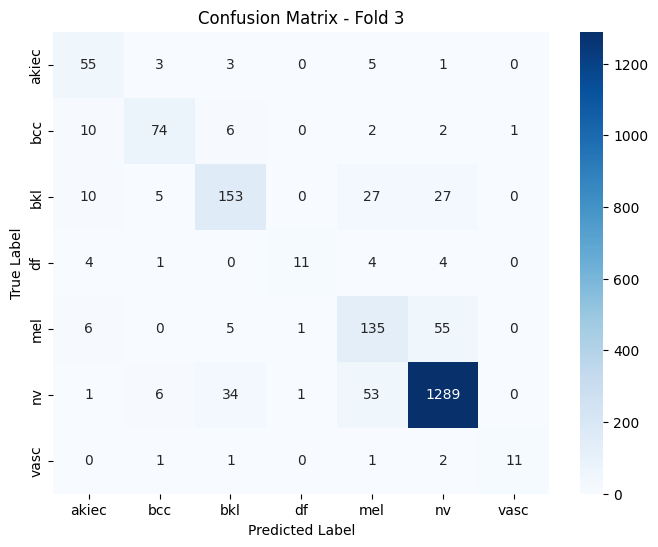

Semua log dan grafik untuk Fold 3 berhasil disimpan di folder: results_exp2_group

---> Memulai Fold 4 <---
Epoch 1/50 - Train Loss: 0.4052 Acc: 0.7488 | Val Loss: 0.2913 Acc: 0.7766
Epoch 2/50 - Train Loss: 0.2048 Acc: 0.8449 | Val Loss: 0.2570 Acc: 0.7845
Epoch 3/50 - Train Loss: 0.1572 Acc: 0.8649 | Val Loss: 0.2441 Acc: 0.8252
Epoch 4/50 - Train Loss: 0.1026 Acc: 0.9054 | Val Loss: 0.2502 Acc: 0.8292
Epoch 5/50 - Train Loss: 0.0708 Acc: 0.9299 | Val Loss: 0.4024 Acc: 0.7830
Epoch 6/50 - Train Loss: 0.1076 Acc: 0.9065 | Val Loss: 0.2631 Acc: 0.8327
Epoch 7/50 - Train Loss: 0.0499 Acc: 0.9494 | Val Loss: 0.2322 Acc: 0.8376
Epoch 8/50 - Train Loss: 0.0364 Acc: 0.9626 | Val Loss: 0.2528 Acc: 0.8332
Epoch 9/50 - Train Loss: 0.0250 Acc: 0.9728 | Val Loss: 0.2609 Acc: 0.8247
Epoch 10/50 - Train Loss: 0.0232 Acc: 0.9745 | Val Loss: 0.2861 Acc: 0.8361
Epoch 11/50 - Train Loss: 0.0187 Acc: 0.9806 | Val Loss: 0.2750 Acc: 0.8361
Epoch 12/50 - Train Loss: 0.0168 Acc: 0.9809 | Val Loss: 0.2846 A

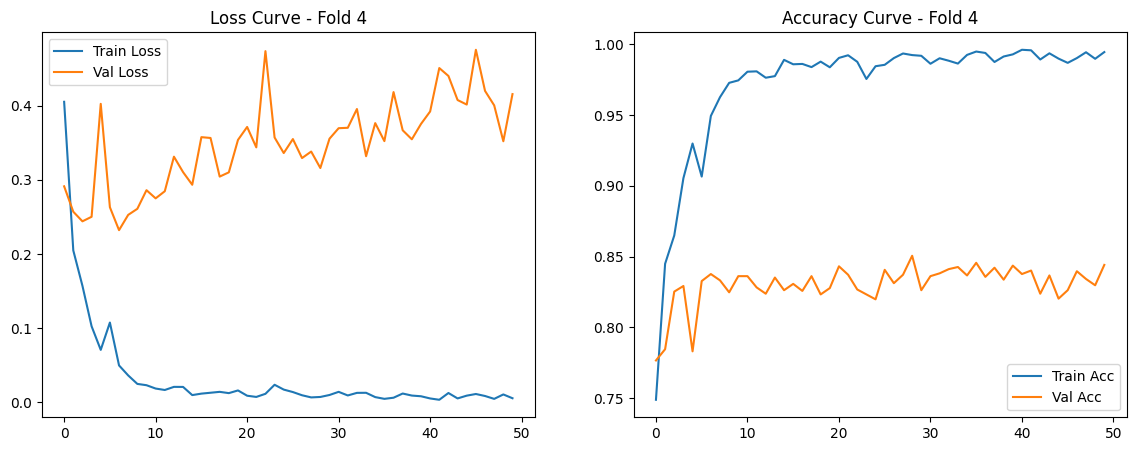

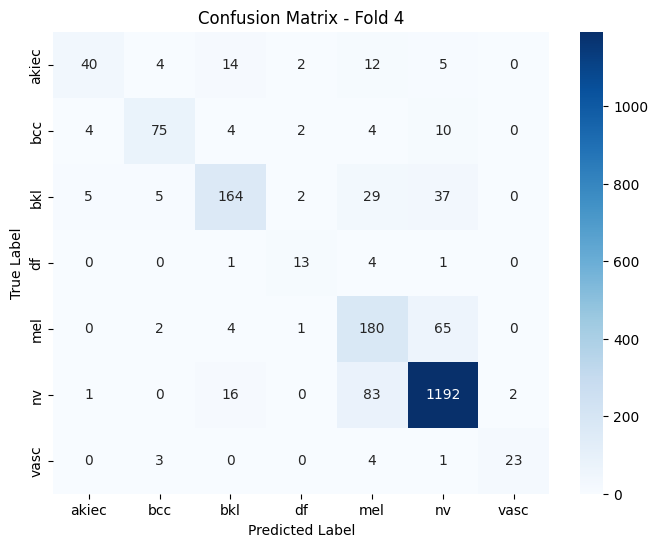

Semua log dan grafik untuk Fold 4 berhasil disimpan di folder: results_exp2_group

---> Memulai Fold 5 <---
Epoch 1/50 - Train Loss: 0.3942 Acc: 0.7563 | Val Loss: 0.2567 Acc: 0.8146
Epoch 2/50 - Train Loss: 0.2079 Acc: 0.8403 | Val Loss: 0.2430 Acc: 0.8318
Epoch 3/50 - Train Loss: 0.1443 Acc: 0.8774 | Val Loss: 0.2044 Acc: 0.8505
Epoch 4/50 - Train Loss: 0.1057 Acc: 0.9030 | Val Loss: 0.2139 Acc: 0.8500
Epoch 5/50 - Train Loss: 0.0814 Acc: 0.9226 | Val Loss: 0.2174 Acc: 0.8364
Epoch 6/50 - Train Loss: 0.0551 Acc: 0.9466 | Val Loss: 0.2141 Acc: 0.8525
Epoch 7/50 - Train Loss: 0.0413 Acc: 0.9551 | Val Loss: 0.2559 Acc: 0.8525
Epoch 8/50 - Train Loss: 0.0358 Acc: 0.9630 | Val Loss: 0.2338 Acc: 0.8545
Epoch 9/50 - Train Loss: 0.0325 Acc: 0.9659 | Val Loss: 0.2699 Acc: 0.8596
Epoch 10/50 - Train Loss: 0.0241 Acc: 0.9751 | Val Loss: 0.2441 Acc: 0.8687
Epoch 11/50 - Train Loss: 0.0195 Acc: 0.9801 | Val Loss: 0.2452 Acc: 0.8652
Epoch 12/50 - Train Loss: 0.0240 Acc: 0.9737 | Val Loss: 0.2370 A

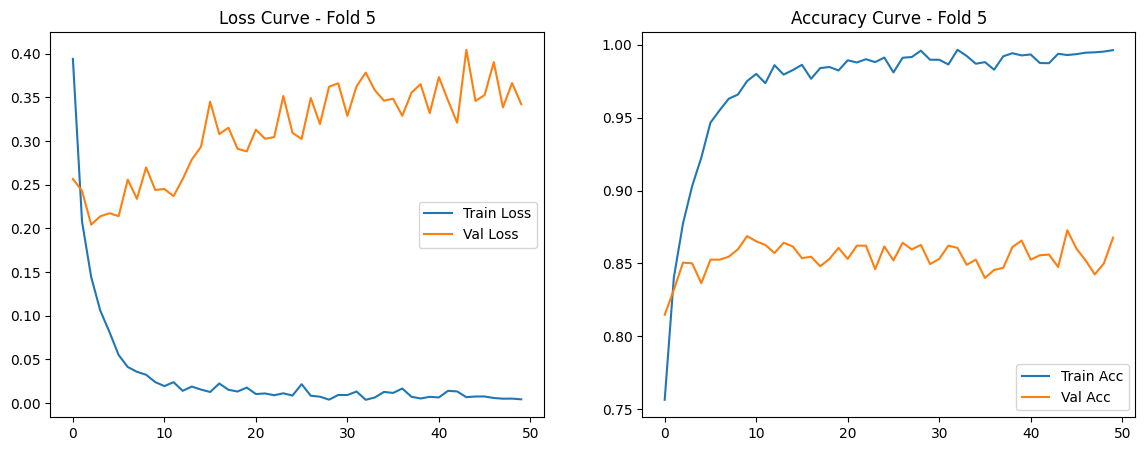

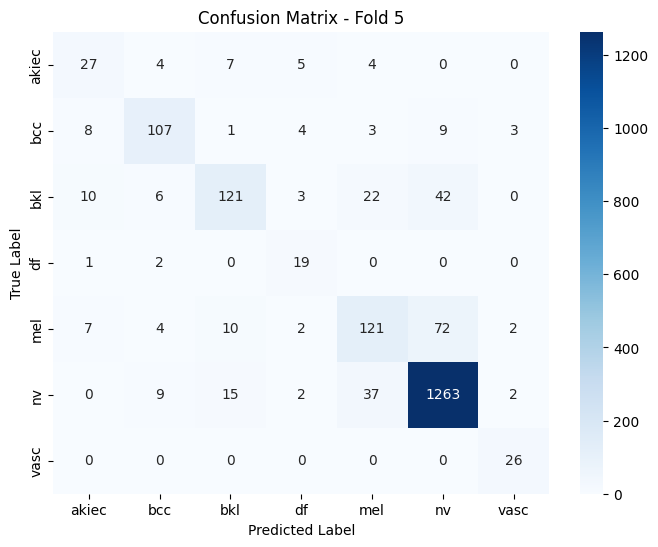

Semua log dan grafik untuk Fold 5 berhasil disimpan di folder: results_exp2_group

ALHAMDULILLAH, EKSPERIMEN 2 SELESAI TOTAL DENGAN STRATIFIED GROUP K-FOLD!
Semua grafik, metric, dan file .pth telah diamankan.


In [8]:
# CELL 7: MASTER EXECUTION LOOP (RUN EXPERIMENT 2 - STRATIFIED GROUP K-FOLD)
import torch.optim as optim

# Hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4

print(f"Mulai Eksperimen 2: ConvNeXt + Spatial Attention + Focal Loss (Grouped by Patient)")
print(f"Menyimpan di folder: {SAVE_DIR}\n" + "="*50)

# BERUBAH: Menggunakan sgkf.split dan menambahkan argumen groups=groups
# Menggunakan start=1 pada enumerate agar fold dihitung dari 1, 2, 3, 4, 5
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups), 1):
    print(f"\n---> Memulai Fold {fold} <---")
    
    # Bagi dataframe berdasarkan index fold (Aman dari kebocoran lesion_id)
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]
    
    # Buat Dataset dan DataLoader
    train_dataset = HAM10000Dataset(train_df, transform=train_transform)
    val_dataset = HAM10000Dataset(val_df, transform=val_transform)
    
    # Gunakan num_workers=4 atau 8 jika CPU Xeon Anda mendukung untuk mempercepat I/O
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Inisialisasi Ulang Model dan Optimizer untuk setiap Fold
    model = ConvNeXt_Spatial_Attention(num_classes=7).to(device)
    criterion = FocalLoss(gamma=2) # Mengatasi Imbalance
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Mulai Training
    history, t_time, max_mem = train_model(
        fold=fold, 
        model=model, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        criterion=criterion, 
        optimizer=optimizer, 
        num_epochs=NUM_EPOCHS
    )
    
    # Mulai Evaluasi & Plotting
    evaluate_and_plot(
        fold=fold, 
        model=model, 
        val_loader=val_loader, 
        history=history, 
        training_time=t_time, 
        max_memory=max_mem, 
        class_names=class_names
    )
    
print("\n" + "="*50)
print("ALHAMDULILLAH, EKSPERIMEN 2 SELESAI TOTAL DENGAN STRATIFIED GROUP K-FOLD!")
print("Semua grafik, metric, dan file .pth telah diamankan.")


In [9]:
# CELL 8: SUMMARY CALCULATOR (MEAN & STD) - FIXED VERSION
import os
import pandas as pd
import glob

# Pastikan path folder benar sesuai hasil running tadi
results_path = "results_exp2_group"
csv_files = glob.glob(os.path.join(results_path, "exp2_fold*_classification_report.csv"))

if len(csv_files) < 5:
    print(f"Peringatan: Baru ditemukan {len(csv_files)} file CSV. Pastikan 5 fold sudah selesai running semua.")
else:
    all_reports = []
    
    for file in csv_files:
        # Perbaikan: index_col=0 digunakan agar kolom pertama (nama kelas) jadi index
        df_fold = pd.read_csv(file, index_col=0) 
        all_reports.append(df_fold)
    
    # Gabungkan semua fold
    full_concat = pd.concat(all_reports)
    
    # Hitung rata-rata (Mean) dan Standar Deviasi (Std)
    mean_report = full_concat.groupby(full_concat.index).mean()
    std_report = full_concat.groupby(full_concat.index).std()

    # Mengambil metrik utama (Accuracy dan Macro F1)
    # Note: Di report sklearn, accuracy biasanya ada di baris 'accuracy' kolom 'precision'
    mean_accuracy = mean_report.loc['accuracy', 'precision']
    mean_macro_f1 = mean_report.loc['macro avg', 'f1-score']
    
    std_accuracy = std_report.loc['accuracy', 'precision']
    std_macro_f1 = std_report.loc['macro avg', 'f1-score']
    
    print("="*50)
    print("   HASIL AKHIR EKSPERIMEN 2 (STATISTIK 5-FOLD)")
    print("="*50)
    print(f"Mean Accuracy : {mean_accuracy:.4f} ± {std_accuracy:.4f}")
    print(f"Mean Macro F1 : {mean_macro_f1:.4f} ± {std_macro_f1:.4f}")
    print("-" * 50)
    
    # Tampilkan tabel lengkap rata-rata per kelas agar bisa langsung di-copy ke Paper
    print("\nLaporan Lengkap (Mean Performance per Class):")
    target_rows = class_names + ['macro avg', 'weighted avg']
    summary_table = mean_report.loc[target_rows, ['precision', 'recall', 'f1-score']]
    
    # Menampilkan tabel
    from IPython.display import display
    display(summary_table)
    
    # Simpan hasil akhir ke CSV untuk arsip
    summary_table.to_csv(os.path.join(results_path, "EXP2_FINAL_SUMMARY_STATISTICS.csv"))
    print(f"\n[INFO] Laporan final telah disimpan di: {results_path}/EXP2_FINAL_SUMMARY_STATISTICS.csv")

   HASIL AKHIR EKSPERIMEN 2 (STATISTIK 5-FOLD)
Mean Accuracy : 0.8515 ± 0.0085
Mean Macro F1 : 0.7396 ± 0.0337
--------------------------------------------------

Laporan Lengkap (Mean Performance per Class):


,precision,recall,f1-score
akiec,0.656843,0.638851,0.635478
bcc,0.777403,0.806294,0.788539
bkl,0.750599,0.694528,0.717595
df,0.770140,0.605781,0.636344
mel,0.634295,0.605239,0.613950
nv,0.920490,0.935596,0.927820
vasc,0.896989,0.838828,0.857381
macro avg,0.772394,0.732160,0.739587
weighted avg,0.852898,0.851531,0.849548



[INFO] Laporan final telah disimpan di: results_exp2_group/EXP2_FINAL_SUMMARY_STATISTICS.csv
